<h1 style="background-color: gray;
           color: black;
           padding: 20px;
           text-align: center;">INFO</h1>

In this script, we compare players `Random1`, `Random2` and `Random3` in a game where there is only one cheese to catch in a maze without mud. \
All programs are evaluated on the same game configurations. \
We do not show the game interface here, to make the script faster. \
The goal is to compare the performances of the different random players in the same conditions.

<h1 style="background-color: gray;
           color: black;
           padding: 20px;
           text-align: center;">IMPORTS</h1>

In [2]:
# External imports
from Dijkstra import Dijkstra
from Dijkstra import Random5



import sys
import os









import tqdm.auto as tqdm









import matplotlib.pyplot as pyplot









import scipy.stats as scstats










# Add needed directories to the path









sys.path.append(os.path.join("..", "players"))










# PyRat imports









from pyrat import Game, GameMode









from Random1 import Random1









from Random2 import Random2









from Random3 import Random3
from Random4 import Random4
from Random5 import Random5
from DFS import DFS
from BFS import BFS
from Dijkstra import Dijkstra


ModuleNotFoundError: No module named 'Dijkstra'

<h1 style="background-color: gray;
           color: black;
           padding: 20px;
           text-align: center;">CONSTANTS</h1>

In this script, we are going to make multiple independent games. \
The goal is to collect enough statistics to draw conclusions on which algorithm is better than the other. \
This constant defines how many games are made.

In [ ]:
# Determines how many games will be played for each player
NB_GAMES = 50

Let's configure the game with a dictionary. \
Note that we put the game mode as `SIMULATION` to perform all games as fast as possible.

In [ ]:
# Customize the game elements
CONFIG = {"mud_percentage": 30,
          "nb_cheese": 1,
          "game_mode": GameMode.SIMULATION}

<h1 style="background-color: gray;
           color: black;
           padding: 20px;
           text-align: center;">RUN THE GAMES</h1>

Let us now perform all games. \
For each game, we remember the number of turns needed to complete it.

In [ ]:
# Players to test (keys are legends to appear in the plot)
players = {"Random 1": {"class": Random1, "args": {}},
           "Random 2": {"class": Random2, "args": {}},
           "Random 3": {"class": Random3, "args": {}},
            "Random 4": {"class": Random4, "args": {}},
            "Random 5": {"class": Random5, "args": {}},
           "DFS": {"class": DFS, "args": {}},
           "BFS": {"class": BFS, "args": {}},
           "Dijkstra": {"class": Dijkstra, "args": {}}
           }


# Run the games for each player
results = {player: [] for player in players}
for key in players:
    for seed in tqdm.tqdm(range(NB_GAMES), desc=key):
        
        # Make the game with given seed
        game = Game(random_seed=seed, **CONFIG)
        player = players[key]["class"](**players[key]["args"])
        game.add_player(player)
        stats = game.start()
        
        # Store the number of turns needed
        results[key].append(stats["turns"])

Random 5: 100%|██████████| 50/50 [00:05<00:00,  8.93it/s]


<h1 style="background-color: gray;
           color: black;
           padding: 20px;
           text-align: center;">ANALYZE THE RESULTS</h1>
           
Now that all games are performed, we plot the percentage of games completed as a function of the number of turns elapsed.

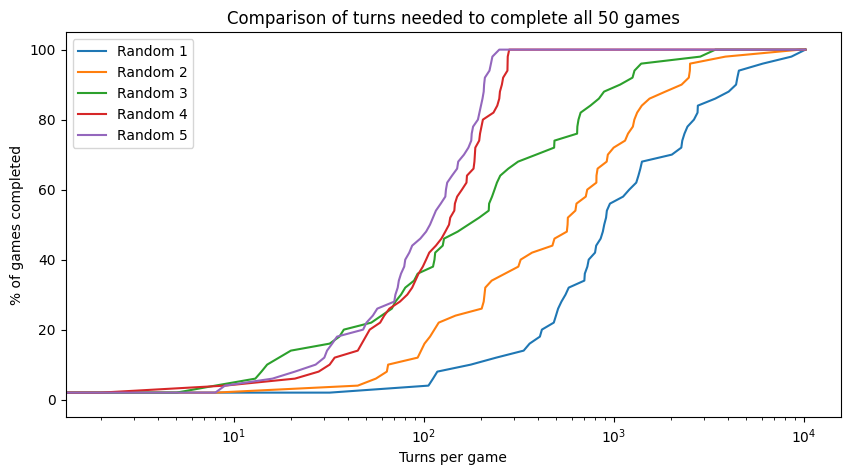

In [ ]:
# Visualization of cumulative curves of numbers of turns taken per program
max_turn = max([max(results[player]) for player in results])
pyplot.figure(figsize=(10, 5))
for player in results:
    turns = [0] + sorted(results[player]) + [max_turn]
    games_completed_per_turn = [len([turn for turn in results[player] if turn <= t]) * 100.0 / NB_GAMES for t in turns]
    pyplot.plot(turns, games_completed_per_turn, label=player)
pyplot.title("Comparison of turns needed to complete all %d games" % (NB_GAMES))
pyplot.xlabel("Turns per game")
pyplot.ylabel("% of games completed")
pyplot.xscale("log")
pyplot.legend()
pyplot.show()

Visualizing is great, but it may be hard to conclude with just a plot. \
Here, we perform a statistical test that will give more insight on whether an algorithm is better than the other.

In [ ]:
# Formal statistics to check if these curves are statistically significant
for i, player_1 in enumerate(results):
    for j, player_2 in enumerate(results):
        if j > i:
            test_result = scstats.mannwhitneyu(results[player_1], results[player_2], alternative="two-sided")
            print("Mann-Whitney U test between turns of program '%s' and of program '%s':" % (player_1, player_2), test_result)

Mann-Whitney U test between turns of program 'Random 1' and of program 'Random 2': MannwhitneyuResult(statistic=np.float64(1652.0), pvalue=np.float64(0.0056419873041595224))
Mann-Whitney U test between turns of program 'Random 1' and of program 'Random 3': MannwhitneyuResult(statistic=np.float64(2050.0), pvalue=np.float64(3.554679108390589e-08))
Mann-Whitney U test between turns of program 'Random 1' and of program 'Random 4': MannwhitneyuResult(statistic=np.float64(2340.5), pvalue=np.float64(5.715329302248973e-14))
Mann-Whitney U test between turns of program 'Random 1' and of program 'Random 5': MannwhitneyuResult(statistic=np.float64(2368.0), pvalue=np.float64(1.3191389672496002e-14))
Mann-Whitney U test between turns of program 'Random 2' and of program 'Random 3': MannwhitneyuResult(statistic=np.float64(1710.5), pvalue=np.float64(0.0015179817355214533))
Mann-Whitney U test between turns of program 'Random 2' and of program 'Random 4': MannwhitneyuResult(statistic=np.float64(2032.5